In [1]:
import sys
import subprocess
import pkgutil

def ensure_package(pkg_name, pip_name=None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installing {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])
    else:
        print(f"{pkg_name} already installed.")

ensure_package("torch_geometric", "torch-geometric")


torch_geometric already installed.


In [310]:
from pathlib import Path

use_day_embedding = True
day_emb_dim       = 3

CONFIG = {
    "BASE_DIR"      : Path("."),
    "PATH_NETWORK"  : Path("./Elec Network Data.xlsx"),
    "PATH_WIND"     : Path("./input/Wind Data.xlsx"),
    "PATH_LOAD"     : Path("./input/Elec Load Data.xlsx"),
    "PATH_DECISION" : Path("./output/Decision_variablesRU.xlsx"),

    "MONTHS"   : [f"{m:02d}" for m in range(1, 13)],
    "NUM_NODES": 45,
    "GENERATOR_BUS_IDX": [6, 12, 14, 15, 18, 26, 27, 28, 32, 35, 37, 39, 41, 43, 44],
    "NUM_GENERATORS": 24,

    "HIST_HOURS"    : 72,
    "HORIZON_HOURS" : 24,
    "STRIDE_HOURS"  : 24,

    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END"  : "2024-11-01 00:00:00",

    "USE_LOAD_HISTORY"         : True,
    "USE_WIND_OFFSHORE_HISTORY": False,
    "USE_WIND_ONSHORE_HISTORY" : False,
    "USE_P_HISTORY"            : False,

    "USE_NODE_STATIC_IS_GENERATOR"   : False,
    "USE_NODE_STATIC_GENERATOR_COUNT": False,
    "USE_NODE_STATIC_PMAX_TOTAL"     : True,
    "USE_NODE_STATIC_LOAD_SHARE"     : False,
    "USE_NODE_STATIC_PV_SHARE"       : False,
    "USE_NODE_STATIC_ONSHORE_SHARE"  : False,
    "USE_NODE_STATIC_IS_OFFSHORE"    : False,
    "USE_NODE_STATIC_IS_IMPORT"      : False,
    "USE_NODE_STATIC_IMPORT_PMAX"    : False,
    "USE_NODE_STATIC_VOLTAGE_KV"     : False,
    "USE_NODE_STATIC_IS_TRANSFER"    : False,
    "USE_NODE_STATIC_DEGREE"         : False,

    "EDGE_STATIC_COLUMNS": ["X_pu", "b_pu", "Pmax_MW", "Length_km", "Inom_A", "UB_kV"],
    "USE_BIDIRECTIONAL_EDGES": True,

    "MODEL_TYPE"          : "gine",
    "HIDDEN_DIM"          : 1024,
    "ENCODER_HIDDEN_DIMS" : [64, 32],
    "DECODER_HIDDEN_DIMS" : [32, 64],
    "NUM_MP_LAYERS"       : 3,
    "DROPOUT"             : 0.1,
    "USE_BATCHNORM"       : True,
    "RESIDUAL"            : True,

    "SEED"                    : 42,
    "DEVICE"                  : "cpu",
    "EPOCHS"                  : 200,
    "BATCH_SIZE"              : 24,
    "LR"                      : 5e-4,
    "WEIGHT_DECAY"            : 1e-5,
    "GRAD_CLIP_NORM"          : 2.0,
    "EARLY_STOPPING_PATIENCE" : 30,
    "EARLY_STOPPING_MIN_DELTA": 1e-4,
    "SCHEDULER_FACTOR"        : 0.4,
    "SCHEDULER_PATIENCE"      : 6,
    "SCHEDULER_MIN_LR"        : 1e-6,

    "NUM_ALIGNMENT_CHECKS" : 5,
    "SAVE_MODEL_STATE"     : False,
    "MODEL_STATE_PATH"     : Path("spatial_elec_gnn.pt"),
}

PATHS = {
    "network" : CONFIG["BASE_DIR"] / CONFIG["PATH_NETWORK"],
    "wind"    : CONFIG["BASE_DIR"] / CONFIG["PATH_WIND"],
    "load"    : CONFIG["BASE_DIR"] / CONFIG["PATH_LOAD"],
    "decision": CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

TRAIN_END = CONFIG["TRAIN_END"]
VAL_END   = CONFIG["VAL_END"]
HIST      = CONFIG["HIST_HOURS"]
HOR       = CONFIG["HORIZON_HOURS"]
STRIDE    = CONFIG["STRIDE_HOURS"]
N_GEN     = len(CONFIG["GENERATOR_BUS_IDX"])

print("Fichiers attendus :")
for k, v in PATHS.items():
    print(f"  {k}: {v.resolve()} | exists={v.exists()}")
for p in PATHS.values():
    assert p.exists(), f"Fichier introuvable: {p}"
print("\nCONFIG OK.")
print(f"use_day_embedding={use_day_embedding}  day_emb_dim={day_emb_dim}")


Fichiers attendus :
  network: C:\Users\yoans\TFE - GAZ\Elec Network Data.xlsx | exists=True
  wind: C:\Users\yoans\TFE - GAZ\input\Wind Data.xlsx | exists=True
  load: C:\Users\yoans\TFE - GAZ\input\Elec Load Data.xlsx | exists=True
  decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True

CONFIG OK.
use_day_embedding=True  day_emb_dim=3


In [198]:
import copy
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, NNConv

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

DEVICE = torch.device(
    "cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu"
)
print("DEVICE =", DEVICE)

def pretty_shape(name, x):
    if isinstance(x, (np.ndarray, torch.Tensor, pd.DataFrame, pd.Series)):
        print(f"{name}: shape={getattr(x, 'shape', None)}")
    else:
        print(f"{name}: type={type(x)}")

def drop_unnamed_first_col(df):
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        return df.drop(columns=[df.columns[0]])
    return df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


DEVICE = cpu


In [199]:
buses_df   = pd.read_excel(PATHS["network"], sheet_name="Buses")
lines_df   = pd.read_excel(PATHS["network"], sheet_name="LinesMerged")
gen_df     = pd.read_excel(PATHS["network"], sheet_name="Gen")
genmap_df  = pd.read_excel(PATHS["network"], sheet_name="GenMap",  header=0)
windmap_df = pd.read_excel(PATHS["network"], sheet_name="WindMap", header=0)
impmap_df  = pd.read_excel(PATHS["network"], sheet_name="ImpMap",  header=0)
imp_df     = pd.read_excel(PATHS["network"], sheet_name="Imp")
renew_df   = pd.read_excel(PATHS["network"], sheet_name="Renew")

num_nodes         = CONFIG["NUM_NODES"]
generator_bus_idx = CONFIG["GENERATOR_BUS_IDX"]

for name, df in [("buses_df", buses_df), ("lines_df", lines_df),
                 ("gen_df", gen_df), ("genmap_df", genmap_df),
                 ("windmap_df", windmap_df), ("impmap_df", impmap_df)]:
    pretty_shape(name, df)

assert len(buses_df)  == num_nodes
assert len(gen_df)    == CONFIG["NUM_GENERATORS"]
assert genmap_df.shape == (num_nodes, CONFIG["NUM_GENERATORS"])
assert windmap_df.shape[0] == num_nodes

print("\nColumns Buses :", list(buses_df.columns))
print("Columns Lines :", list(lines_df.columns))
print("Columns Gen   :", list(gen_df.columns))
display(buses_df.head())
display(lines_df.head())
display(gen_df)


buses_df: shape=(45, 9)
lines_df: shape=(65, 18)
gen_df: shape=(24, 14)
genmap_df: shape=(45, 24)
windmap_df: shape=(45, 1)
impmap_df: shape=(45, 8)

Columns Buses : ['Node', 'Name', 'Province', 'Type', 'UB_kV', 'Transfos', 'Load_share_%', 'Pv_share_%', 'Onshore_share_%']
Columns Lines : ['Line', 'FromNode', 'ToNode', 'FromNodeName', 'ToNodeName', 'UB_kV', 'Length_km', 'Inom_A', 'R_ohm', 'X_ohm', 'b_S', 'Zb', 'b_pu', 'X_pu', 'wC_µS', 'Pmax_MW', 'Lat_from', 'Long_from']
Columns Gen   : ['Generator', 'Name', 'NodeName', 'Node', 'Gas node', 'Pmin_MW', 'Pmax_MW', 'Type', 'Fuel', 'Ramp rate [%/h]', 'Efficiency', 'VOM_€/MWh', 'FuelCost_€/MWh_fuel', 'Year ']


,Node,Name,Province,Type,UB_kV,Transfos,Load_share_%,Pv_share_%,Onshore_share_%
0,1,ACHEN,Namur,Load,380,270,1.541360,1.727500,5.799500
1,2,AUBAN220,Luxembourg,Load,220,240,1.370098,0.548000,0.864750
2,3,AUBAN380,Luxembourg,Load,380,30,0.171262,0.000000,0.000000
3,4,AVLGM,WV,Load,380,1035,5.908546,8.010000,4.370500
4,5,AWIRS,Liege,Load,220,560,3.196894,0.644818,0.893182


,Line,FromNode,ToNode,FromNodeName,ToNodeName,UB_kV,Length_km,Inom_A,R_ohm,X_ohm,b_S,Zb,b_pu,X_pu,wC_µS,Pmax_MW,Lat_from,Long_from
0,1,1,17,ACHEN,GRAMM,380,36.9,1999,1.140000,12.100000,0.082645,1444,119.338843,0.008380,141.47,1315.700434,50.267829,5.045634
1,2,3,8,AUBAN380,BRUME,380,104.4,2186,3.550000,32.880000,0.030414,1444,43.917275,0.022770,379.36,1438.779965,49.563838,5.799276
2,3,4,18,AVLGM,HORTA,380,39.7,4185,0.620008,6.505001,0.153728,1444,221.983221,0.004505,299.85,2754.480399,50.774131,3.445316
3,4,4,19,AVLGM,IZGEM,380,22.8,4372,0.355000,3.740000,0.267380,1444,386.096257,0.002590,175.30,2877.559930,50.774131,3.445316
4,5,7,28,BRUEG,MEKI+,380,14,1999,0.450000,4.630000,0.215983,1444,311.879050,0.003206,54.18,1315.700434,50.838519,4.262445


,Generator,Name,NodeName,Node,Gas node,Pmin_MW,Pmax_MW,Type,Fuel,Ramp rate [%/h],Efficiency,VOM_€/MWh,FuelCost_€/MWh_fuel,Year
0,1,Vilvoorde GT,VERBR,42,13.0,0,360.0,CCGT-GT,Gas,0.5,0.52,2.0,0.00,2001.0
1,2,Syral Aalst GT,BRUEG,7,24.0,0,48.0,CCGT-GT (CHP),Gas,0.5,0.45,3.3,0.00,2000.0
2,3,DOEL 1-2-4,DOEL,13,NaN,0,1929.0,NU,Uranium,0.1,0.33,9.0,1.87,NaN
3,4,HERDERSBRUG,GEZEL,15,2.0,0,480.3,CCGT-GT,Gas,0.5,0.51,2.0,0.00,1998.0
4,5,Fluxys LNG Zeebrugge WKK,GEZEL,15,2.0,0,40.0,OCGT (CHP),Gas,0.5,0.45,15.0,0.00,1987.0
5,6,Marcinelle + Saint-Ghi + Amercoeur,GOUY,16,27.0,0,1242.0,CCGT,Gas,0.5,0.54,2.0,0.00,2001.0
6,7,IZEGEM,IZGEM,19,3.0,0,20.0,CCGT (CHP),Gas,0.5,0.34,15.0,0.00,1995.0
7,8,T-Power,MEERH,27,11.0,0,425.0,CCGT,Gas,1.0,0.58,2.0,0.00,2011.0
8,9,DROGENBOS,MEKI+,28,24.0,0,460.0,CCGT-GT,Gas,0.5,0.52,2.0,0.00,1993.0
9,10,Borealis + Scheldelaan,MERCA,29,8.0,0,172.0,CCGT (CHP),Gas,0.6,0.45,3.3,0.00,2009.0


In [200]:
genmap = genmap_df.to_numpy(dtype=float)

generator_to_bus = {}
for gen_idx in range(CONFIG["NUM_GENERATORS"]):
    connected = np.where(genmap[:, gen_idx] > 0.5)[0]
    assert len(connected) == 1, f"Gen {gen_idx} connecté à {len(connected)} bus"
    generator_to_bus[gen_idx] = int(connected[0])

print("Mapping gen → bus (0-based):")
for g, b in generator_to_bus.items():
    print(f"  Gen{g+1:2d} → Bus {b+1:2d} ({buses_df.iloc[b]['Name']})")

pmax_per_bus = np.zeros(num_nodes, dtype=float)
for gen_idx, bus_idx in generator_to_bus.items():
    pmax_val = gen_df.iloc[gen_idx]["Pmax_MW"]
    if isinstance(pmax_val, str):
        pmax_val = eval(pmax_val.replace("=", ""))
    pmax_per_bus[bus_idx] += float(pmax_val)

gen_count_per_bus = np.zeros(num_nodes, dtype=int)
for gen_idx, bus_idx in generator_to_bus.items():
    gen_count_per_bus[bus_idx] += 1

gen_buses_from_map = sorted(set(generator_to_bus.values()))
assert gen_buses_from_map == sorted(CONFIG["GENERATOR_BUS_IDX"])
print(f"\n{len(gen_buses_from_map)} gen bus (0-based): {gen_buses_from_map}")

windmap        = windmap_df.to_numpy(dtype=float).flatten()
offshore_bus_idx = np.where(windmap > 0.5)[0]
assert len(offshore_bus_idx) == 1 and offshore_bus_idx[0] == 38
print(f"Bus offshore : bus {offshore_bus_idx[0]} (STEVN), windmap OK")

impmap = impmap_df.to_numpy(dtype=float)
is_import_bus  = (impmap.sum(axis=1) > 0).astype(float)
import_pmax_mw = np.zeros(num_nodes, dtype=float)
for i in range(num_nodes):
    for j in range(8):
        if impmap[i, j] > 0.5:
            import_pmax_mw[i] += float(imp_df.iloc[j]["Pmax_MW"])

print(f"Interconnected bus (1-based): {np.where(is_import_bus > 0)[0] + 1}")


Mapping gen → bus (0-based):
  Gen 1 → Bus 42 (VERBR)
  Gen 2 → Bus  7 (BRUEG)
  Gen 3 → Bus 13 (DOEL)
  Gen 4 → Bus 15 (GEZEL)
  Gen 5 → Bus 15 (GEZEL)
  Gen 6 → Bus 16 (GOUY)
  Gen 7 → Bus 19 (IZGEM)
  Gen 8 → Bus 27 (MEERH)
  Gen 9 → Bus 28 (MEKI+)
  Gen10 → Bus 29 (MERCA)
  Gen11 → Bus 29 (MERCA)
  Gen12 → Bus 29 (MERCA)
  Gen13 → Bus 29 (MERCA)
  Gen14 → Bus 29 (MERCA)
  Gen15 → Bus 33 (RODE+)
  Gen16 → Bus 33 (RODE+)
  Gen17 → Bus 33 (RODE+)
  Gen18 → Bus 33 (RODE+)
  Gen19 → Bus 36 (SERAI)
  Gen20 → Bus 36 (SERAI)
  Gen21 → Bus 38 (STAM+)
  Gen22 → Bus 40 (TIHA1)
  Gen23 → Bus 44 (ZANDV)
  Gen24 → Bus 45 (ZUTE+)

15 gen bus (0-based): [6, 12, 14, 15, 18, 26, 27, 28, 32, 35, 37, 39, 41, 43, 44]
Bus offshore : bus 38 (STEVN), windmap OK
Interconnected bus (1-based): [ 1  2  4 16 23 30 41 44]


In [201]:
transfos = buses_df["Transfos"].to_numpy(dtype=float)

load_share_pct = buses_df["Load_share_%"].to_numpy(dtype=float)
pv_share_pct = buses_df["Pv_share_%"].to_numpy(dtype=float)
onshore_share_pct = buses_df["Onshore_share_%"].to_numpy(dtype=float)

load_share = load_share_pct / 100.0
pv_share_norm = pv_share_pct / 100.0
onshore_share_norm = onshore_share_pct / 100.0

print("Sum load_share       =", load_share.sum())
print("Sum pv_share_norm    =", pv_share_norm.sum())
print("Sum onshore_share_norm =", onshore_share_norm.sum())

display(pd.DataFrame({
    "Name": buses_df["Name"],
    "Transfos": transfos,
    "Load_share_%": load_share_pct,
    "Pv_share_%": pv_share_pct,
    "Onshore_share_%": onshore_share_pct,
}).head(10))

Sum load_share       = 1.0
Sum pv_share_norm    = 0.9999500000000001
Sum onshore_share_norm = 0.9999600000000001


,Name,Transfos,Load_share_%,Pv_share_%,Onshore_share_%
0,ACHEN,270.0,1.541360,1.727500,5.799500
1,AUBAN220,240.0,1.370098,0.548000,0.864750
2,AUBAN380,30.0,0.171262,0.000000,0.000000
3,AVLGM,1035.0,5.908546,8.010000,4.370500
4,AWIRS,560.0,3.196894,0.644818,0.893182
5,BERN,0.0,0.000000,0.000000,0.000000
6,BRUEG,1260.0,7.193013,5.153333,1.716667
7,BRUME,297.0,1.695496,0.644818,0.893182
8,BUGG+,0.0,0.000000,0.000000,0.000000
9,CHAMP,492.0,2.808700,1.727500,5.799500


In [202]:
def read_decision_p(months, decision_path):
    all_arrays = []
    for m in months:
        df = pd.read_excel(decision_path, sheet_name=f"p-{m}-2024", header=0, index_col=0)
        all_arrays.append(df.to_numpy(dtype=float))
    p_full = np.concatenate(all_arrays, axis=0)
    ts_p   = pd.date_range("2024-01-01", periods=len(p_full), freq="h")
    return p_full, ts_p

def read_elec_load(months, load_path):
    dfs = []
    for m in months:
        df = pd.read_excel(load_path, sheet_name=f"{m}-2024", header=0, usecols=[0, 1])
        df.columns = ["datetime", "load_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df[["datetime", "load_MW"]])
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["load_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])

def read_wind(months, wind_path):
    dfs = []
    for m in months:
        df = pd.read_excel(wind_path, sheet_name=f"{m}-2024", header=0, usecols=[0, 1])
        df.columns = ["datetime", "wind_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df[["datetime", "wind_MW"]])
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["wind_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])


In [203]:
p_full,     ts_p    = read_decision_p(CONFIG["MONTHS"], PATHS["decision"])
load_total, ts_load = read_elec_load(CONFIG["MONTHS"],  PATHS["load"])
wind_total, ts_wind = read_wind(CONFIG["MONTHS"],       PATHS["wind"])

assert len(ts_p) == len(ts_load) == len(ts_wind)
assert p_full.shape[1] == 24

T = len(ts_p)
print("Plage temporelle :", ts_p.min(), "->", ts_p.max())
print("Nombre total d'heures :", T)

pretty_shape("p_full [T, 24]",   p_full)
pretty_shape("load_total [T]",   load_total)
pretty_shape("wind_total [T]",   wind_total)


Plage temporelle : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Nombre total d'heures : 8784
p_full [T, 24]: shape=(8784, 24)
load_total [T]: shape=(8784,)
wind_total [T]: shape=(8784,)


In [204]:
p_bus_full = np.zeros((T, num_nodes), dtype=float)
for gen_idx, bus_idx in generator_to_bus.items():
    p_bus_full[:, bus_idx] += p_full[:, gen_idx]

p_bus_generator = p_bus_full[:, CONFIG["GENERATOR_BUS_IDX"]]

np.testing.assert_allclose(p_bus_full.sum(axis=1), p_full.sum(axis=1), rtol=1e-6)
print("Agrégation p par bus OK.")

load_nodal          = load_total[:, None] * load_share[None, :]
wind_offshore_nodal = np.zeros((T, num_nodes), dtype=float)
wind_offshore_nodal[:, 38] = wind_total
wind_onshore_nodal  = wind_total[:, None] * onshore_share_norm[None, :]
p_history_nodal     = p_bus_full.copy()

pretty_shape("p_bus_generator [T, 15]",    p_bus_generator)
pretty_shape("load_nodal [T, 45]",         load_nodal)
pretty_shape("wind_offshore_nodal [T, 45]",wind_offshore_nodal)


Agrégation p par bus OK.
p_bus_generator [T, 15]: shape=(8784, 15)
load_nodal [T, 45]: shape=(8784, 45)
wind_offshore_nodal [T, 45]: shape=(8784, 45)


In [205]:
dyn_feature_dict = {}

if CONFIG["USE_LOAD_HISTORY"]:
    dyn_feature_dict["load_nodal"] = load_nodal
if CONFIG["USE_WIND_OFFSHORE_HISTORY"]:
    dyn_feature_dict["wind_offshore"] = wind_offshore_nodal
if CONFIG["USE_WIND_ONSHORE_HISTORY"]:
    dyn_feature_dict["wind_onshore"] = wind_onshore_nodal
if CONFIG["USE_P_HISTORY"]:
    dyn_feature_dict["p_history"] = p_history_nodal

assert len(dyn_feature_dict) > 0, "Au moins une feature dynamique doit être activée."

dyn_feature_names = list(dyn_feature_dict.keys())
dyn_tensor        = np.stack([dyn_feature_dict[k] for k in dyn_feature_names], axis=-1)

print("Features dynamiques :", dyn_feature_names)
pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)

display(pd.DataFrame({
    "feature": dyn_feature_names,
    "shape"  : [str(dyn_feature_dict[k].shape) for k in dyn_feature_names],
    "min"    : [dyn_feature_dict[k].min()  for k in dyn_feature_names],
    "max"    : [dyn_feature_dict[k].max()  for k in dyn_feature_names],
    "mean"   : [dyn_feature_dict[k].mean() for k in dyn_feature_names],
}))


Features dynamiques : ['load_nodal']
dyn_tensor [T, N, F_dyn]: shape=(8784, 45, 1)


,feature,shape,min,max,mean
0,load_nodal,"(8784, 45)",0.0,837.813792,152.119565


In [206]:
degrees = np.zeros(num_nodes, dtype=float)
for _, row in lines_df.iterrows():
    u = int(row["FromNode"]) - 1
    v = int(row["ToNode"])   - 1
    degrees[u] += 1
    degrees[v] += 1

is_transfer = (buses_df["Type"] == "Transfer").to_numpy(dtype=float)
voltage_kv  = buses_df["UB_kV"].to_numpy(dtype=float)

node_static_parts = []
node_static_names = []

_ns = [
    ("USE_NODE_STATIC_IS_GENERATOR",    lambda: (gen_count_per_bus > 0).astype(float)[:, None],          "is_generator"),
    ("USE_NODE_STATIC_GENERATOR_COUNT", lambda: gen_count_per_bus[:, None].astype(float),                "generator_count"),
    ("USE_NODE_STATIC_PMAX_TOTAL",      lambda: pmax_per_bus[:, None],                                   "pmax_total_MW"),
    ("USE_NODE_STATIC_LOAD_SHARE",      lambda: load_share[:, None],                                     "load_share"),
    ("USE_NODE_STATIC_PV_SHARE",        lambda: pv_share_norm[:, None],                                  "pv_share"),
    ("USE_NODE_STATIC_ONSHORE_SHARE",   lambda: onshore_share_norm[:, None],                             "onshore_share"),
    ("USE_NODE_STATIC_IS_OFFSHORE",     lambda: windmap[:, None],                                        "is_offshore_wind"),
    ("USE_NODE_STATIC_IS_IMPORT",       lambda: is_import_bus[:, None],                                  "is_import_bus"),
    ("USE_NODE_STATIC_IMPORT_PMAX",     lambda: import_pmax_mw[:, None],                                 "import_pmax_MW"),
    ("USE_NODE_STATIC_VOLTAGE_KV",      lambda: voltage_kv[:, None],                                     "voltage_kV"),
    ("USE_NODE_STATIC_IS_TRANSFER",     lambda: is_transfer[:, None],                                    "is_transfer"),
    ("USE_NODE_STATIC_DEGREE",          lambda: degrees[:, None],                                        "degree"),
]

for key, builder, name in _ns:
    if CONFIG.get(key, False):
        node_static_parts.append(builder())
        node_static_names.append(name)

node_static = (
    np.concatenate(node_static_parts, axis=1)
    if node_static_parts
    else np.zeros((num_nodes, 0), dtype=float)
)

pretty_shape("node_static [N, F_static]", node_static)
print("node_static_names =", node_static_names)


node_static [N, F_static]: shape=(45, 1)
node_static_names = ['pmax_total_MW']


In [207]:
edge_static_cols = CONFIG["EDGE_STATIC_COLUMNS"]
edge_static_base = (
    lines_df[edge_static_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .to_numpy(dtype=float)
)

edge_pairs = []
edge_attrs = []
for i, row in lines_df.iterrows():
    u  = int(row["FromNode"]) - 1
    v  = int(row["ToNode"])   - 1
    ea = edge_static_base[i]
    edge_pairs.append((u, v))
    edge_attrs.append(ea)
    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs.append((v, u))
        edge_attrs.append(ea.copy())

edge_index    = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw = np.array(edge_attrs, dtype=float)

assert edge_index.shape[0] == 2
assert edge_index.max() < num_nodes
assert edge_attr_raw.shape == (edge_index.shape[1], len(edge_static_cols))

print("edge_static_cols =", edge_static_cols)
print("Nb arêtes :", edge_index.shape[1])
pretty_shape("edge_index", edge_index)
pretty_shape("edge_attr_raw", edge_attr_raw)


edge_static_cols = ['X_pu', 'b_pu', 'Pmax_MW', 'Length_km', 'Inom_A', 'UB_kV']
Nb arêtes : 130
edge_index: shape=torch.Size([2, 130])
edge_attr_raw: shape=(130, 6)


In [208]:
ts_p = pd.to_datetime(ts_p)

day_of_week = ts_p.dayofweek.to_numpy(dtype=np.int64)
is_weekend  = (day_of_week >= 5).astype(np.int64)

#pd.DataFrame({
    #"datetime"   : ts_p[:8],
    #"day_of_week": day_of_week[:8],
    #"is_weekend" : is_weekend[:8],
#}).pipe(display)


In [209]:
TRAIN_END_ts = pd.Timestamp(TRAIN_END)
VAL_END_ts   = pd.Timestamp(VAL_END)

train_time_mask = ts_p < TRAIN_END_ts
val_time_mask   = (ts_p >= TRAIN_END_ts) & (ts_p < VAL_END_ts)
test_time_mask  = ts_p >= VAL_END_ts

print("Train hours :", int(train_time_mask.sum()))
print("Val hours   :", int(val_time_mask.sum()))
print("Test hours  :", int(test_time_mask.sum()))

T, N_nodes, F_dyn = dyn_tensor.shape

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[train_time_mask].reshape(-1, F_dyn))
dyn_tensor_scaled = dyn_scaler.transform(dyn_tensor.reshape(-1, F_dyn)).reshape(T, N_nodes, F_dyn)

node_static_scaler = StandardScaler()
node_static_scaler.fit(node_static)
node_static_scaled = node_static_scaler.transform(node_static)

edge_scaler = StandardScaler()
edge_scaler.fit(edge_attr_raw)
edge_attr_scaled = edge_scaler.transform(edge_attr_raw)

target_scaler = StandardScaler()
target_scaler.fit(p_bus_generator[train_time_mask])
p_bus_gen_scaled = target_scaler.transform(p_bus_generator)

print("\nTarget scaler mean shape :", target_scaler.mean_.shape)
print("Target scaler scale shape:", target_scaler.scale_.shape)
pretty_shape("dyn_tensor_scaled    [T, N_nodes, F_dyn]", dyn_tensor_scaled)
pretty_shape("node_static_scaled   [N_nodes, F_static]", node_static_scaled)
pretty_shape("edge_attr_scaled     [N_edges, F_edge]",   edge_attr_scaled)
pretty_shape("p_bus_gen_scaled     [T, N_GEN]",          p_bus_gen_scaled)
print("\nNormalisation OK.")


Train hours : 6576
Val hours   : 744
Test hours  : 1464

Target scaler mean shape : (15,)
Target scaler scale shape: (15,)
dyn_tensor_scaled    [T, N_nodes, F_dyn]: shape=(8784, 45, 1)
node_static_scaled   [N_nodes, F_static]: shape=(45, 1)
edge_attr_scaled     [N_edges, F_edge]: shape=(130, 6)
p_bus_gen_scaled     [T, N_GEN]: shape=(8784, 15)

Normalisation OK.


In [210]:
all_start_indices = np.arange(0, T - HIST - HOR + 1, STRIDE)

forecast_starts   = pd.DatetimeIndex([ts_p[i + HIST] for i in all_start_indices])
train_window_mask = forecast_starts < TRAIN_END_ts
val_window_mask   = (forecast_starts >= TRAIN_END_ts) & (forecast_starts < VAL_END_ts)
test_window_mask  = forecast_starts >= VAL_END_ts

print(f"Nombre total de fenêtres : {len(all_start_indices)}")
print(f"  Train : {int(train_window_mask.sum())}")
print(f"  Val   : {int(val_window_mask.sum())}")
print(f"  Test  : {int(test_window_mask.sum())}")

expected_x_dim = HIST * F_dyn + node_static_scaled.shape[1]
print(f"\nexpected_x_dim (sans embedding) = {expected_x_dim}")
print(f"N_GEN = {N_GEN}")

def build_single_window(start_idx):
    hist_dyn = dyn_tensor_scaled[start_idx : start_idx + HIST]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2)).reshape(num_nodes, -1)
    x        = np.concatenate([hist_dyn, node_static_scaled], axis=1)

    y      = p_bus_gen_scaled[start_idx + HIST : start_idx + HIST + HOR].T
    y_real = p_bus_generator[start_idx + HIST  : start_idx + HIST + HOR].T

    dow_idx = int(day_of_week[start_idx + HIST])

    return {
        "x"                : x.astype(np.float32),
        "y"                : y.astype(np.float32),
        "y_real"           : y_real.astype(np.float32),
        "dow"              : dow_idx,
        "start_idx"        : np.int64(start_idx),
        "target_start_idx" : np.int64(start_idx + HIST),
        "target_end_idx"   : np.int64(start_idx + HIST + HOR - 1),
    }

sample0 = build_single_window(int(all_start_indices[0]))
assert sample0["x"].shape == (num_nodes, expected_x_dim)
assert sample0["y"].shape == (N_GEN, HOR)
print("\nbuild_single_window OK.")

def check_alignment(start_idx, verbose=True):
    s = build_single_window(start_idx)
    ts0, ts1 = int(s["target_start_idx"]), int(s["target_end_idx"])
    expected = p_bus_generator[ts0:ts1+1].T
    assert np.allclose(expected, s["y_real"]), "Problème d'alignement y_real"
    if verbose:
        print(f"Alignment OK | start={start_idx} | {ts_p[ts0]} → {ts_p[ts1]}")

for idx in [all_start_indices[0], all_start_indices[10], all_start_indices[-1]]:
    check_alignment(int(idx))


Nombre total de fenêtres : 363
  Train : 271
  Val   : 31
  Test  : 61

expected_x_dim (sans embedding) = 73
N_GEN = 15

build_single_window OK.
Alignment OK | start=0 | 2024-01-04 00:00:00 → 2024-01-04 23:00:00
Alignment OK | start=240 | 2024-01-14 00:00:00 → 2024-01-14 23:00:00
Alignment OK | start=8688 | 2024-12-31 00:00:00 → 2024-12-31 23:00:00


In [211]:
class ElecSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx):
        s = build_single_window(int(self.start_indices[idx]))
        data = Data(
            x          = torch.tensor(s["x"],           dtype=torch.float32),
            edge_index = edge_index.clone(),
            edge_attr  = torch.tensor(edge_attr_scaled, dtype=torch.float32),
            y          = torch.tensor(s["y"],           dtype=torch.float32),
            generator_mask = torch.tensor(
                np.isin(np.arange(num_nodes), CONFIG["GENERATOR_BUS_IDX"]),
                dtype=torch.bool
            ),
        )
        data.dow              = int(s["dow"])
        data.start_idx        = int(s["start_idx"])
        data.target_start_idx = int(s["target_start_idx"])
        data.target_end_idx   = int(s["target_end_idx"])
        data.y_real           = torch.tensor(s["y_real"], dtype=torch.float32)
        return data

train_ds = ElecSpatialWindowDataset(all_start_indices[train_window_mask])
val_ds   = ElecSpatialWindowDataset(all_start_indices[val_window_mask])
test_ds  = ElecSpatialWindowDataset(all_start_indices[test_window_mask])

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print(f"len(train_ds) = {len(train_ds)}")
print(f"len(val_ds)   = {len(val_ds)}")
print(f"len(test_ds)  = {len(test_ds)}")

batch = next(iter(train_loader))
print(batch)
pretty_shape("batch.x",              batch.x)
pretty_shape("batch.edge_attr",      batch.edge_attr)
pretty_shape("batch.y",              batch.y)
pretty_shape("batch.generator_mask", batch.generator_mask)
assert batch.x.shape[1]         == expected_x_dim
assert batch.edge_attr.shape[1] == edge_attr_scaled.shape[1]
assert batch.y.shape[-1]        == HOR


len(train_ds) = 271
len(val_ds)   = 31
len(test_ds)  = 61
DataBatch(x=[1080, 73], edge_index=[2, 3120], edge_attr=[3120, 6], y=[360, 24], generator_mask=[1080], dow=[24], start_idx=[24], target_start_idx=[24], target_end_idx=[24], y_real=[360, 24], batch=[1080], ptr=[25])
batch.x: shape=torch.Size([1080, 73])
batch.edge_attr: shape=torch.Size([3120, 6])
batch.y: shape=torch.Size([360, 24])
batch.generator_mask: shape=torch.Size([1080])


In [212]:
class MLP(nn.Module):
    def __init__(self, dims, dropout=0.0, use_batchnorm=False, activate_last=False):
        super().__init__()
        self.dims         = list(dims)
        self.in_channels  = self.dims[0]
        self.out_channels = self.dims[-1]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            is_last = (i == len(dims) - 2)
            if (not is_last) or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(dims[i+1]))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [213]:
class SpatialElecGNN(nn.Module):
    def __init__(
        self,
        in_dim,
        edge_dim,
        hidden_dim,
        horizon,
        model_type="gine",
        encoder_hidden_dims=(4, 2),
        decoder_hidden_dims=(2, 4),
        num_mp_layers=3,
        dropout=0.0,
        use_batchnorm=True,
        residual=True,
        use_day_embedding=False,
        day_emb_dim=3,
    ):
        super().__init__()
        self.model_type       = model_type.lower()
        self.residual         = residual
        self.num_mp_layers    = num_mp_layers
        self.use_day_embedding = use_day_embedding

        if use_day_embedding:
            self.day_embedding = nn.Embedding(7, day_emb_dim)
            enc_in_dim = in_dim + day_emb_dim
        else:
            enc_in_dim = in_dim

        enc_dims = [enc_in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_mp_layers):
            if self.model_type == "nnconv":
                edge_net = MLP([edge_dim, hidden_dim, hidden_dim * hidden_dim],
                               dropout=dropout, use_batchnorm=False, activate_last=False)
                conv = NNConv(hidden_dim, hidden_dim, nn=edge_net, aggr="mean")
            elif self.model_type == "gine":
                nn_mlp = MLP([hidden_dim, hidden_dim, hidden_dim],
                              dropout=dropout, use_batchnorm=False, activate_last=False)
                nn_mlp.in_channels = hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=edge_dim)
            else:
                raise ValueError(f"MODEL_TYPE : {model_type}")
            self.convs.append(conv)
            self.norms.append(
                nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
            )

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr, generator_mask, dow=None, batch_idx=None):
        if self.use_day_embedding and dow is not None and batch_idx is not None:
            dow_emb      = self.day_embedding(dow)
            dow_expanded = dow_emb[batch_idx]
            x = torch.cat([x, dow_expanded], dim=1)

        h = self.encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h    = conv(h, edge_index, edge_attr)
            h    = norm(h)
            h    = F.relu(h)
            if self.residual:
                h = h + h_in

        h_gen = h[generator_mask]
        return self.decoder(h_gen)


model = SpatialElecGNN(
    in_dim              = expected_x_dim,
    edge_dim            = edge_attr_scaled.shape[1],
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    model_type          = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers       = CONFIG["NUM_MP_LAYERS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    residual            = CONFIG["RESIDUAL"],
    use_day_embedding   = use_day_embedding,
    day_emb_dim         = day_emb_dim,
).to(DEVICE)

print(model)

test_batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    dow_t   = torch.tensor(test_batch.dow, dtype=torch.long).to(DEVICE) if isinstance(test_batch.dow, list) else test_batch.dow.to(DEVICE)
    test_pred = model(
        test_batch.x, test_batch.edge_index, test_batch.edge_attr,
        test_batch.generator_mask,
        dow=dow_t if use_day_embedding else None,
        batch_idx=test_batch.batch if use_day_embedding else None,
    )
print("\nForward OK  test_pred.shape =", test_pred.shape)
assert test_pred.shape == test_batch.y.view(-1, HOR).shape


SpatialElecGNN(
  (day_embedding): Embedding(7, 3)
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=76, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.05, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.05, inplace=False)
      (8): Linear(in_features=128, out_features=8, bias=True)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=8, out_features=8, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.05, inplace=False)
        (3): Linear(in_features=8, out_features=8, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-1): 2 x BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [214]:
def mse_loss_on_generators(pred, batch):
    y_true = batch.y.view_as(pred)
    return F.mse_loss(pred, y_true)

def inverse_targets_flexible(arr_scaled, n_gen=N_GEN, horizon=HOR):
    arr = np.asarray(arr_scaled)
    scaler_shape = np.asarray(target_scaler.mean_).shape

    if scaler_shape in [(1,), ()]:
        return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

    if len(scaler_shape) == 1 and scaler_shape[0] == n_gen:
        if arr.ndim == 2:
            bsz  = arr.shape[0] // n_gen
            arr2 = arr.reshape(bsz, n_gen, horizon).transpose(0, 2, 1).reshape(-1, n_gen)
            return target_scaler.inverse_transform(arr2).reshape(bsz, horizon, n_gen).transpose(0, 2, 1).reshape(arr.shape)
        if arr.ndim == 3:
            bsz  = arr.shape[0]
            arr2 = arr.transpose(0, 2, 1).reshape(-1, n_gen)
            return target_scaler.inverse_transform(arr2).reshape(bsz, horizon, n_gen).transpose(0, 2, 1)

    raise ValueError(f"target_scaler incompatible: mean_.shape={scaler_shape}")

def mae_rmse_nmae(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true).reshape(-1), np.asarray(y_pred).reshape(-1)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nmae = mae / (np.mean(np.abs(y_true)) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_samples = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        dow_t = batch.dow.to(DEVICE) if hasattr(batch.dow, "to") else torch.tensor(batch.dow, dtype=torch.long).to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(
                batch.x, batch.edge_index, batch.edge_attr, batch.generator_mask,
                dow=dow_t if use_day_embedding else None,
                batch_idx=batch.batch if use_day_embedding else None,
            )
            loss = mse_loss_on_generators(pred, batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()
        total_loss    += loss.item() * batch.num_graphs
        total_samples += batch.num_graphs
    return total_loss / max(total_samples, 1)


In [215]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = np.inf
        self.best_state  = None
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


In [311]:
model = SpatialElecGNN(
    in_dim              = expected_x_dim,
    edge_dim            = edge_attr_scaled.shape[1],
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    model_type          = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers       = CONFIG["NUM_MP_LAYERS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    residual            = CONFIG["RESIDUAL"],
    use_day_embedding   = use_day_embedding,
    day_emb_dim         = day_emb_dim,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"], min_lr=CONFIG["SCHEDULER_MIN_LR"],
)
early_stopper = EarlyStopping(
    patience  = CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta = CONFIG["EARLY_STOPPING_MIN_DELTA"],
)
history = {"train_loss": [], "val_loss": [], "lr": []}

print(model)
print("\nModèle / optimizer / scheduler / history reinitialized.")


SpatialElecGNN(
  (day_embedding): Embedding(7, 3)
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=76, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=64, out_features=32, bias=True)
      (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=32, out_features=1024, bias=True)
    )
  )
  (convs): ModuleList(
    (0-2): 3 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=1024, out_features=1024, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=1024, out_features=1024, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [312]:
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss   = run_one_epoch(model, val_loader,   optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_loss:.6f} | val={val_loss:.6f} | "
        f"counter={early_stopper.counter}/{early_stopper.patience} | lr={current_lr:.2e}"
    )

    if early_stopper.step(val_loss, model):
        print(f"Early stopping triggered at epoch {epoch}.")
        break

assert early_stopper.best_state is not None
model.load_state_dict(early_stopper.best_state)
print("\nMeilleur val_loss:", early_stopper.best_loss)

if CONFIG["SAVE_MODEL_STATE"]:
    torch.save(model.state_dict(), CONFIG["MODEL_STATE_PATH"])
    print("Modèle sauvegardé dans", CONFIG["MODEL_STATE_PATH"])


Epoch 001 | train=1.046566 | val=0.915045 | counter=0/30 | lr=5.00e-04
Epoch 002 | train=0.932690 | val=0.813490 | counter=0/30 | lr=5.00e-04
Epoch 003 | train=0.883974 | val=0.747781 | counter=0/30 | lr=5.00e-04
Epoch 004 | train=0.845472 | val=0.819630 | counter=0/30 | lr=5.00e-04
Epoch 005 | train=0.807959 | val=0.762645 | counter=1/30 | lr=5.00e-04
Epoch 006 | train=0.775730 | val=0.889705 | counter=2/30 | lr=5.00e-04
Epoch 007 | train=0.788799 | val=0.854187 | counter=3/30 | lr=5.00e-04
Epoch 008 | train=0.774347 | val=0.820308 | counter=4/30 | lr=5.00e-04
Epoch 009 | train=0.778853 | val=0.812173 | counter=5/30 | lr=5.00e-04
Epoch 010 | train=0.736654 | val=0.808999 | counter=6/30 | lr=2.00e-04
Epoch 011 | train=0.728318 | val=0.830107 | counter=7/30 | lr=2.00e-04
Epoch 012 | train=0.724395 | val=0.758527 | counter=8/30 | lr=2.00e-04
Epoch 013 | train=0.722481 | val=0.727190 | counter=9/30 | lr=2.00e-04
Epoch 014 | train=0.713788 | val=0.770924 | counter=0/30 | lr=2.00e-04
Epoch 

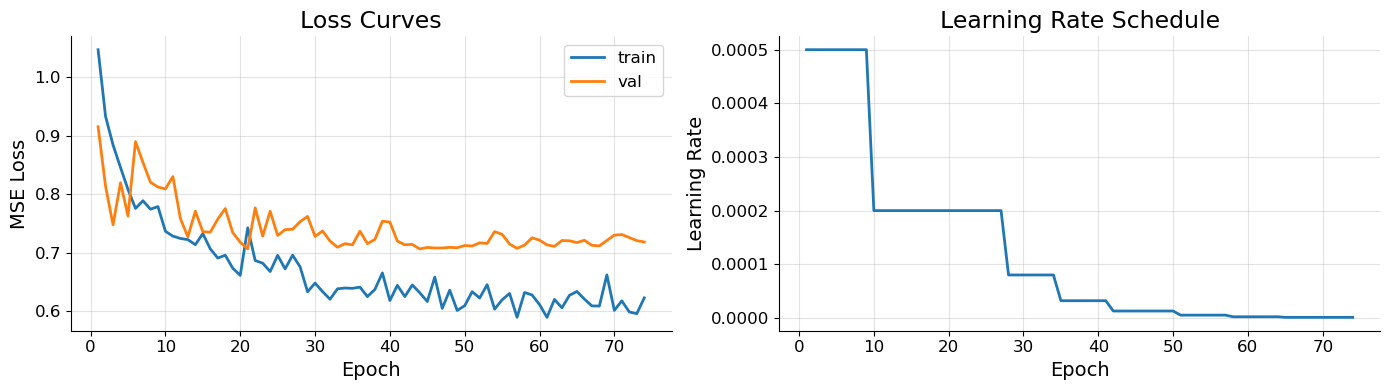

Training completed in 74 epochs.
Best val_loss = 0.706489


In [313]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_ran, history["train_loss"], label="train")
ax1.plot(epochs_ran, history["val_loss"], label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Loss Curves"); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, history["lr"])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule"); ax2.grid(True)

plt.tight_layout()
plt.show()
print(f"Training completed in {len(history['train_loss'])} epochs.")
print(f"Best val_loss = {early_stopper.best_loss:.6f}")


In [314]:
def ensure_3d_output(arr, n_gen, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_gen and arr.shape[2] == horizon
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon
        assert arr.shape[0] % n_gen == 0
        return arr.reshape(arr.shape[0] // n_gen, n_gen, horizon)
    raise ValueError(f"ndim non supporté: {arr.ndim}")

@torch.no_grad()
def collect_predictions(mdl, loader):
    mdl.eval()
    preds_scaled, trues_scaled, preds_real, trues_real, metas = [], [], [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        dow_t = batch.dow.to(DEVICE) if hasattr(batch.dow, "to") else torch.tensor(batch.dow, dtype=torch.long).to(DEVICE)
        pred  = mdl(
            batch.x, batch.edge_index, batch.edge_attr, batch.generator_mask,
            dow=dow_t if use_day_embedding else None,
            batch_idx=batch.batch if use_day_embedding else None,
        )
        pred_np = pred.detach().cpu().numpy()
        true_np = batch.y.detach().cpu().numpy()
        preds_scaled.append(pred_np)
        trues_scaled.append(true_np)
        preds_real.append(inverse_targets_flexible(pred_np))
        trues_real.append(inverse_targets_flexible(true_np))
        if hasattr(batch, "target_start_idx"):
            metas.append(batch.target_start_idx.detach().cpu().numpy())

    return {
        "preds_scaled": np.concatenate(preds_scaled, axis=0),
        "trues_scaled": np.concatenate(trues_scaled, axis=0),
        "preds_real"  : np.concatenate(preds_real,   axis=0),
        "trues_real"  : np.concatenate(trues_real,   axis=0),
        "metas"       : np.concatenate(metas, axis=0) if metas else np.array([]),
    }

train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)

for split, out in [("train", train_out), ("val", val_out), ("test", test_out)]:
    print(f"{split} | preds_real={out['preds_real'].shape} | trues_real={out['trues_real'].shape}")


train | preds_real=(4065, 24) | trues_real=(4065, 24)
val | preds_real=(465, 24) | trues_real=(465, 24)
test | preds_real=(915, 24) | trues_real=(915, 24)


In [315]:
def diagnose_alignment(out, n_checks=5):
    preds_3d = ensure_3d_output(out["preds_real"], N_GEN, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_GEN, HOR)
    metas    = np.asarray(out["metas"]).reshape(-1)
    n = min(n_checks, len(metas), len(trues_3d))
    for k in range(n):
        ts0      = int(metas[k])
        expected = p_bus_generator[ts0 : ts0 + HOR].T
        assert np.allclose(expected, trues_3d[k], atol=1e-6), f"Erreur alignement k={k}"
        print(f"k={k} | target_start={ts0} | {ts_p[ts0]} → {ts_p[ts0+HOR-1]} | OK")

diagnose_alignment(test_out, n_checks=CONFIG["NUM_ALIGNMENT_CHECKS"])
print("Diagnostic d'alignement test OK.")


k=0 | target_start=7320 | 2024-11-01 00:00:00 → 2024-11-01 23:00:00 | OK
k=1 | target_start=7344 | 2024-11-02 00:00:00 → 2024-11-02 23:00:00 | OK
k=2 | target_start=7368 | 2024-11-03 00:00:00 → 2024-11-03 23:00:00 | OK
k=3 | target_start=7392 | 2024-11-04 00:00:00 → 2024-11-04 23:00:00 | OK
k=4 | target_start=7416 | 2024-11-05 00:00:00 → 2024-11-05 23:00:00 | OK
Diagnostic d'alignement test OK.


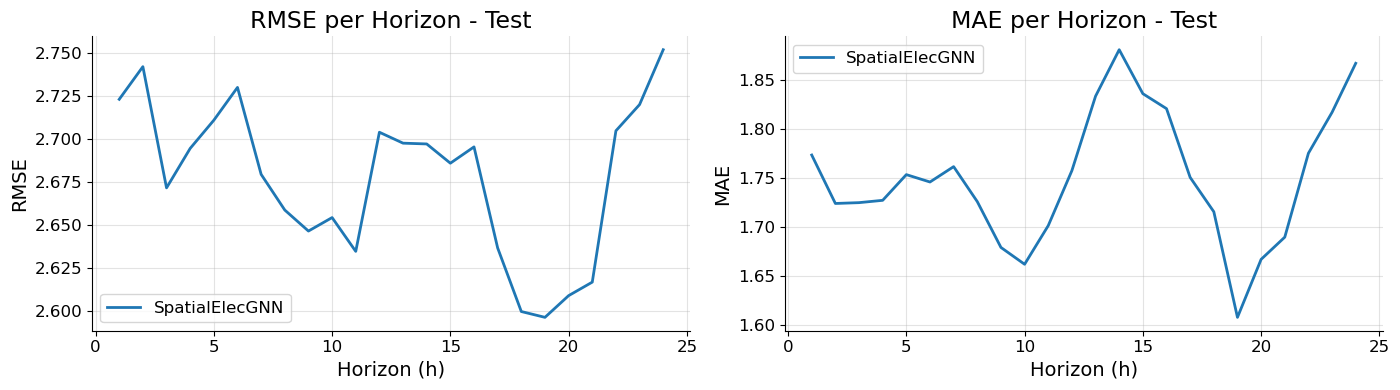

In [316]:
def per_horizon_metrics(y_true, y_pred):
    y_true_3d = ensure_3d_output(y_true, N_GEN, HOR)
    y_pred_3d = ensure_3d_output(y_pred, N_GEN, HOR)
    rows = []
    for h in range(HOR):
        m = mae_rmse_nmae(y_true_3d[:, :, h], y_pred_3d[:, :, h])
        rows.append({"h": h + 1, **m})
    return pd.DataFrame(rows)

test_horizon_df = per_horizon_metrics(test_out["trues_real"], test_out["preds_real"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(test_horizon_df["h"], test_horizon_df["RMSE"], label="SpatialElecGNN")
ax1.set(xlabel="Horizon (h)", ylabel="RMSE", title="RMSE per Horizon - Test")
ax1.legend(); ax1.grid(True)

ax2.plot(test_horizon_df["h"], test_horizon_df["MAE"], label="SpatialElecGNN")
ax2.set(xlabel="Horizon (h)", ylabel="MAE", title="MAE per Horizon - Test")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()


In [317]:
true_cont = np.full((T, N_GEN), np.nan)
pred_cont = np.full((T, N_GEN), np.nan)

preds_3d = ensure_3d_output(test_out["preds_real"], N_GEN, HOR)
metas = test_out["metas"]
assert len(metas) == len(preds_3d)

for k, ts0 in enumerate(metas):
    ts0 = int(ts0)
    for j in range(N_GEN):
        true_cont[ts0 : ts0 + HOR, j] = p_bus_generator[ts0 : ts0 + HOR, j]
        pred_cont[ts0 : ts0 + HOR, j] = preds_3d[k, j, :]

n_valid = int(np.sum(np.any(~np.isnan(true_cont), axis=1)))
print(f"Continuous reconstruction: {n_valid} valid hours out of {T}")


Continuous reconstruction: 1464 valid hours out of 8784


Zoom 72h de 2024-11-01 00:00:00 à 2024-11-03 23:00:00


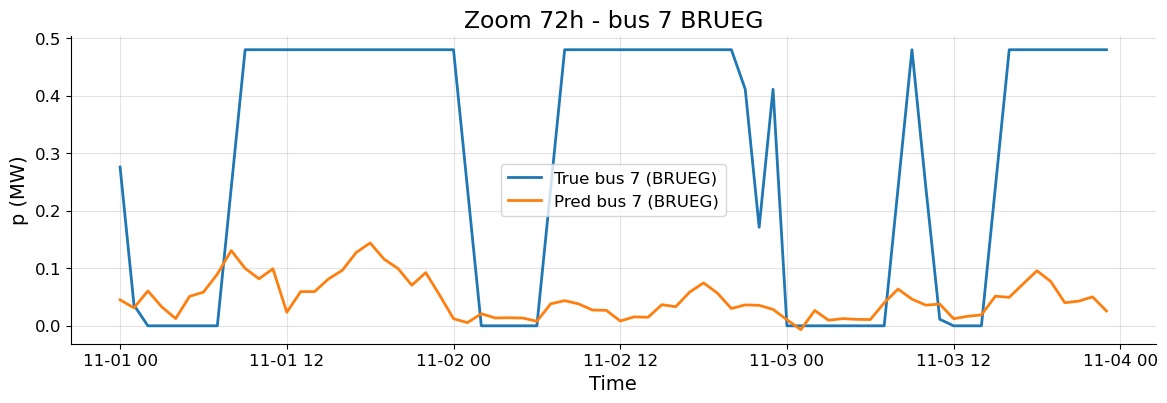

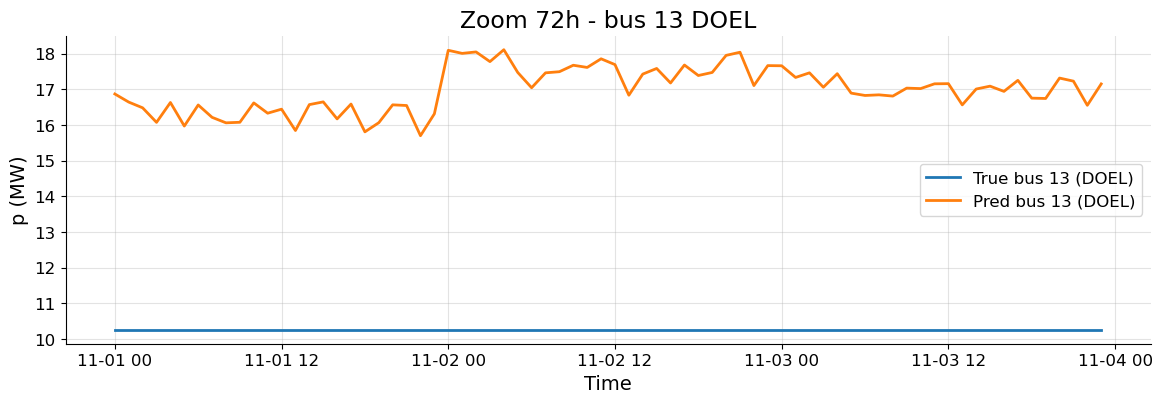

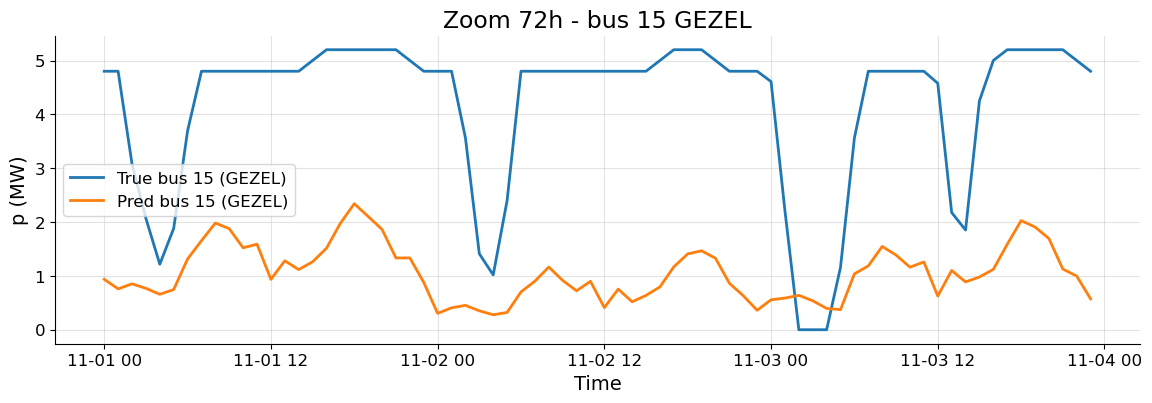

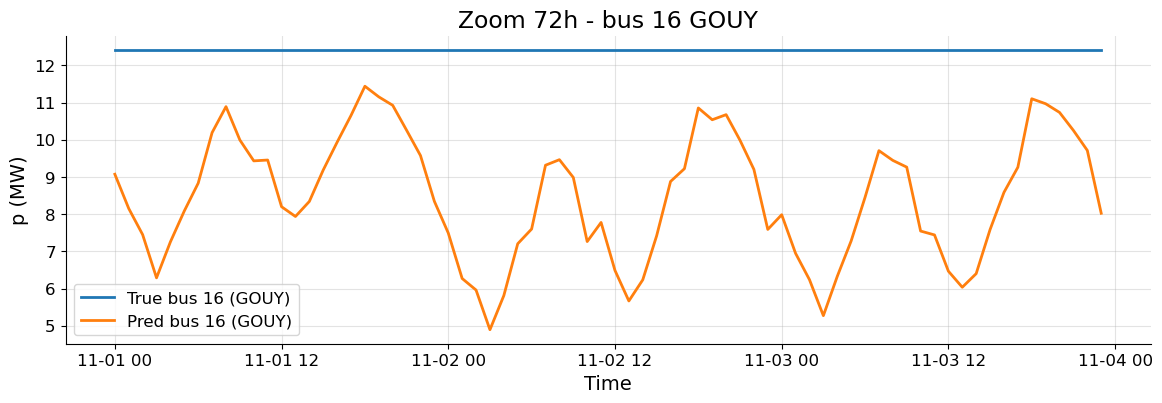

In [318]:
N_ZOOM = 72
valid_hours_mask = np.any(~np.isnan(true_cont), axis=1)
valid_idx        = np.where(valid_hours_mask)[0]
start_plot       = valid_idx[0]
end_plot         = min(start_plot + N_ZOOM, T)

print("Zoom 72h de", ts_p[start_plot], "à", ts_p[end_plot - 1])

for j in range(min(4, N_GEN)):
    bus_idx  = CONFIG["GENERATOR_BUS_IDX"][j]
    bus_name = buses_df.iloc[bus_idx]["Name"]
    plt.figure(figsize=(14, 4))
    plt.plot(ts_p[start_plot:end_plot], true_cont[start_plot:end_plot, j],
             label=f"True bus {bus_idx+1} ({bus_name})")
    plt.plot(ts_p[start_plot:end_plot], pred_cont[start_plot:end_plot, j],
             label=f"Pred bus {bus_idx+1} ({bus_name})")
    plt.title(f"Zoom 72h - bus {bus_idx+1} {bus_name}")
    plt.xlabel("Time"); plt.ylabel("p (MW)"); plt.grid(True); plt.legend()
    plt.show()


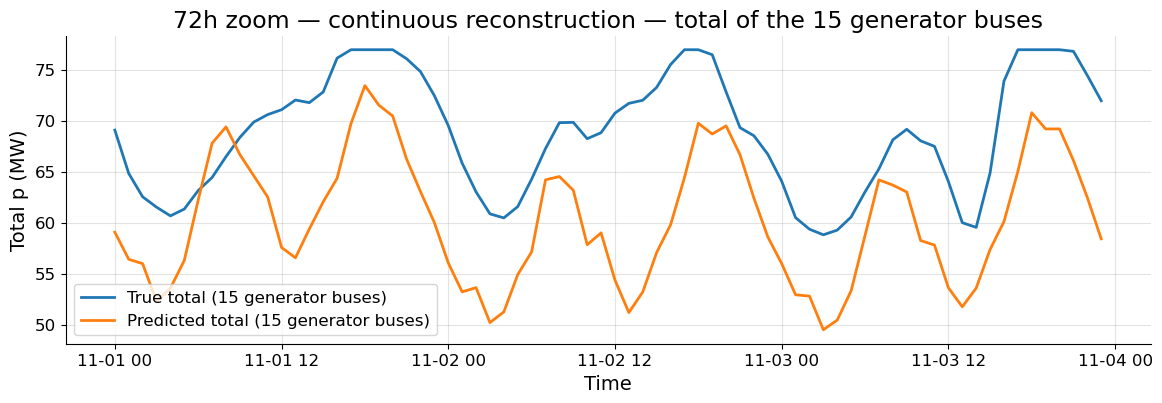

In [319]:
true_total_72h = np.nansum(true_cont[start_plot:end_plot, :], axis=1)
pred_total_72h = np.nansum(pred_cont[start_plot:end_plot, :], axis=1)

plt.figure(figsize=(14, 4))
plt.plot(ts_p[start_plot:end_plot], true_total_72h, label="True total (15 generator buses)")
plt.plot(ts_p[start_plot:end_plot], pred_total_72h, label="Predicted total (15 generator buses)")
plt.title("72h zoom — continuous reconstruction — total of the 15 generator buses")
plt.xlabel("Time")
plt.ylabel("Total p (MW)")
plt.grid(True)
plt.legend()
plt.show()


In [320]:
ts_ = ts_p
dyn_tensor_ = dyn_tensor
dyn_feature_names_ = dyn_feature_names
p_target_ = p_bus_generator
GEN_IDX_ = CONFIG["GENERATOR_BUS_IDX"]
N_GEN_ = N_GEN
HOR_ = HOR
test_out_ = test_out
buses_df_ = buses_df

def _to_3d_pred(arr, n_gen, hor):
    return ensure_3d_output(arr, n_gen, hor)

def mae_rmse(y_true, y_pred):
    y_true_f = np.asarray(y_true).reshape(-1)
    y_pred_f = np.asarray(y_pred).reshape(-1)
    return {
        "MAE": float(np.mean(np.abs(y_true_f - y_pred_f))),
        "RMSE": float(np.sqrt(np.mean((y_true_f - y_pred_f) ** 2))),
    }

print("Diagnostic aliases defined (ts_, dyn_tensor_, p_target_, test_out_, etc.)")


Diagnostic aliases defined (ts_, dyn_tensor_, p_target_, test_out_, etc.)


,horizon_h,model_MAE,model_RMSE
0,1,1.773268,2.722894
1,2,1.723930,2.741838
2,3,1.724773,2.671495
3,4,1.727136,2.694410
4,5,1.753313,2.710769
5,6,1.745802,2.729795
6,7,1.761449,2.679345
7,8,1.725805,2.658628
8,9,1.679148,2.646443
9,10,1.662017,2.654263


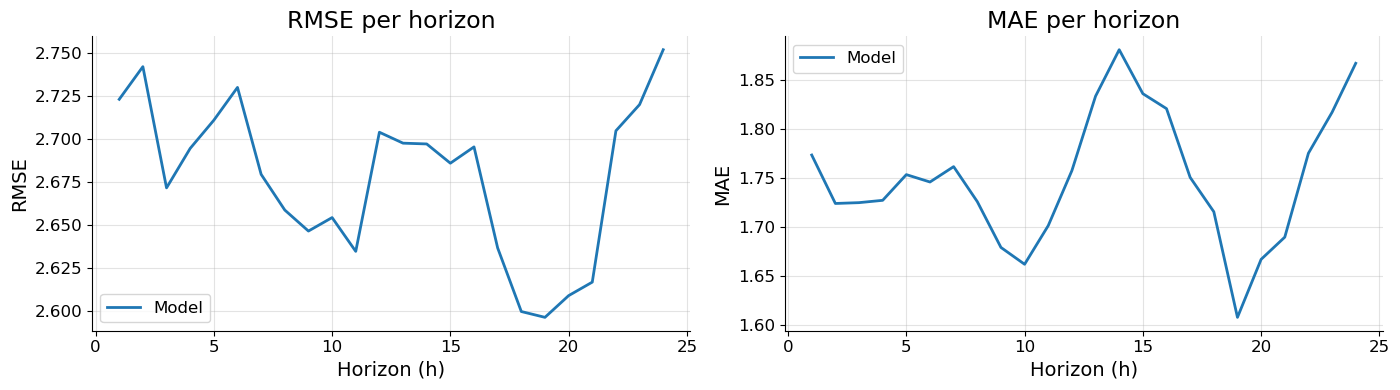

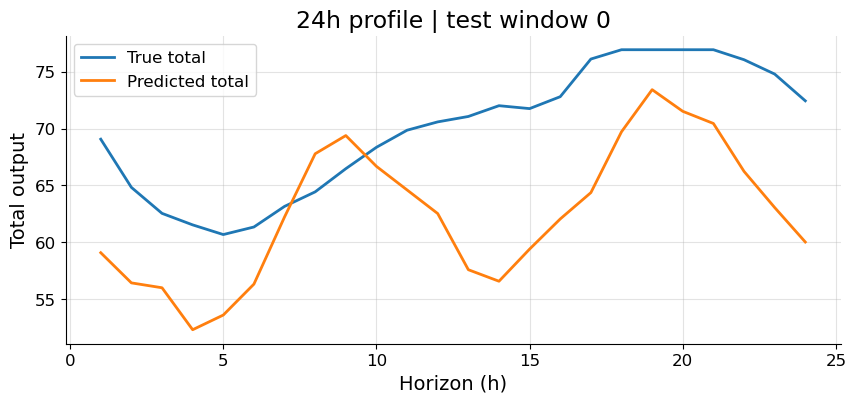

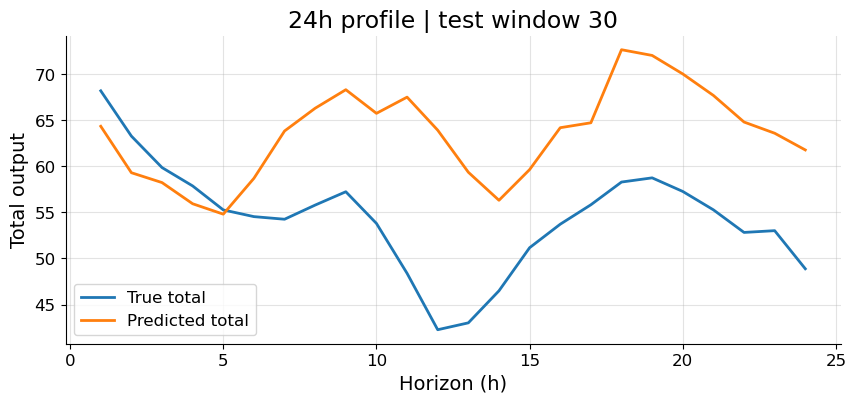

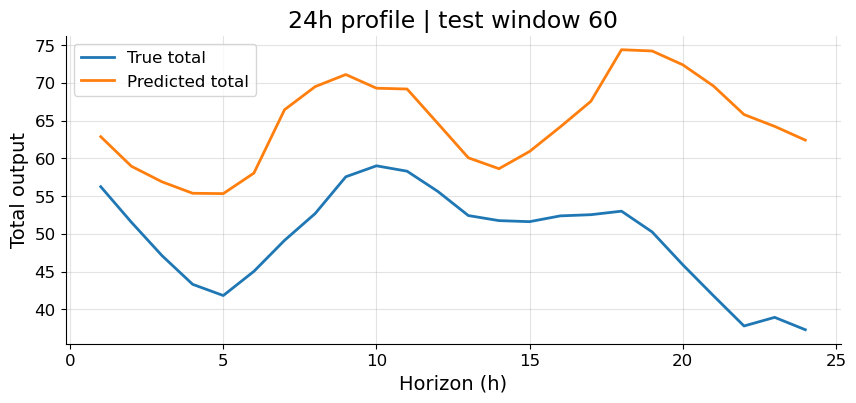

In [321]:
y_true3 = _to_3d_pred(test_out_["trues_real"], N_GEN_, HOR_)
y_pred3 = _to_3d_pred(test_out_["preds_real"], N_GEN_, HOR_)

rows = []
for h in range(HOR_):
    m = mae_rmse(y_true3[:, :, h], y_pred3[:, :, h])
    rows.append({
        "horizon_h": h + 1,
        "model_MAE": m["MAE"],
        "model_RMSE": m["RMSE"],
    })

horizon_df = pd.DataFrame(rows)
display(horizon_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(horizon_df["horizon_h"], horizon_df["model_RMSE"], label="Model")
axes[0].set_title("RMSE per horizon")
axes[0].set_xlabel("Horizon (h)")
axes[0].set_ylabel("RMSE")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(horizon_df["horizon_h"], horizon_df["model_MAE"], label="Model")
axes[1].set_title("MAE per horizon")
axes[1].set_xlabel("Horizon (h)")
axes[1].set_ylabel("MAE")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

sel = np.linspace(0, len(y_true3) - 1, min(3, len(y_true3))).astype(int)
for k in sel:
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, HOR_ + 1), np.sum(y_true3[k], axis=0), label="True total")
    plt.plot(np.arange(1, HOR_ + 1), np.sum(y_pred3[k], axis=0), label="Predicted total")
    plt.title(f"24h profile | test window {k}")
    plt.xlabel("Horizon (h)")
    plt.ylabel("Total output")
    plt.grid(True)
    plt.legend()
    plt.show()


GIANT DIAGNOSTIC CELL — GNN Spatial Elec

--- SECTION : Error per prediction horizon (test set) ---


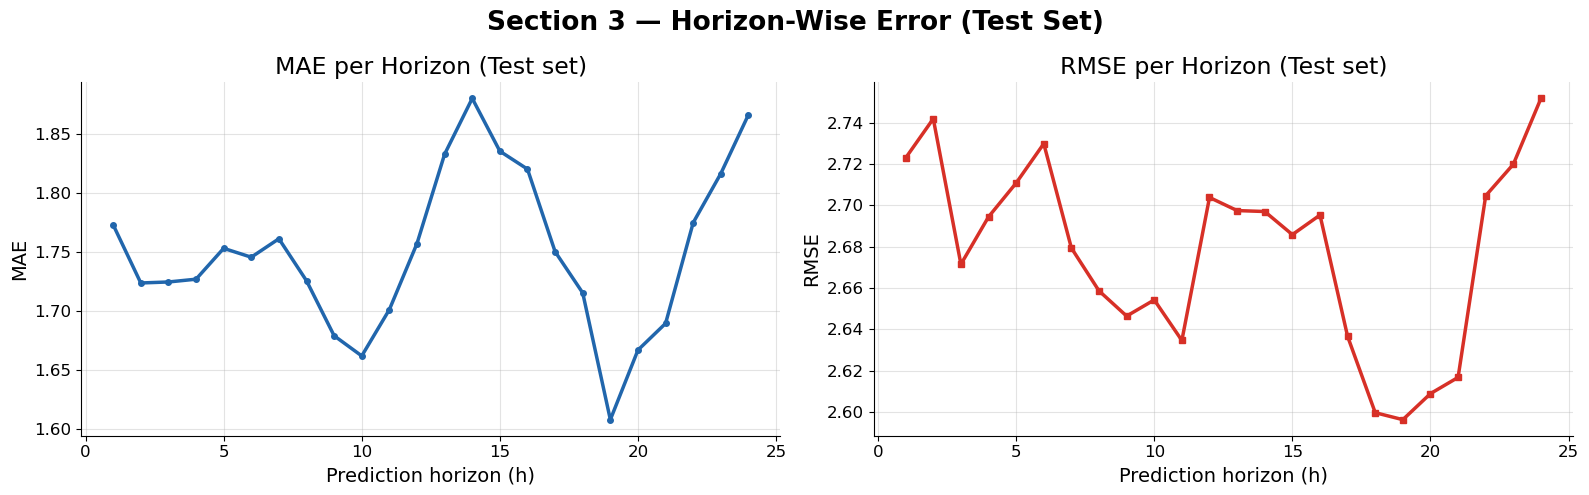

  RMSE h=1: 2.7229  |  RMSE h=24: 2.7517

--- SECTION : Smoothing analysis ---
  Mean per-node STD ratio : 0.504
  Aggregated STD ratio    : 0.601
  % buses with ratio < 0.8: 100.0%


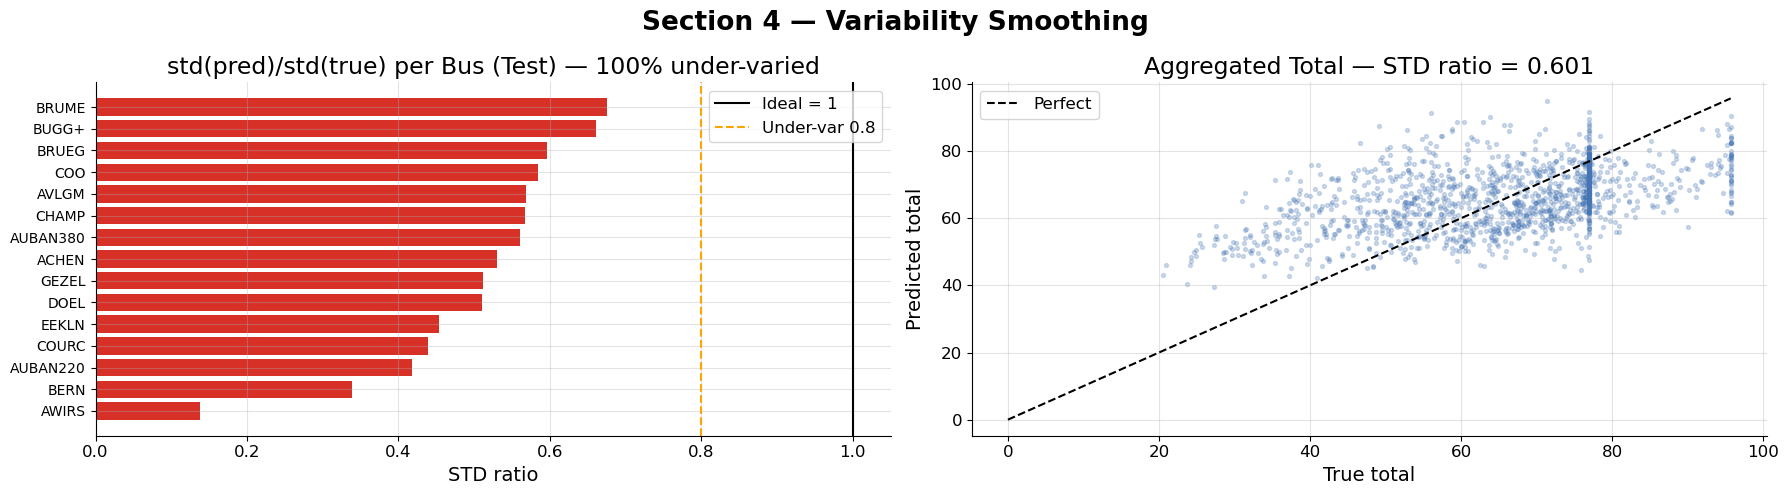


--- SECTION : Dynamic feature – target correlation (lag = horizon) ---
   feature  corr_t+24h
load_nodal    0.582999


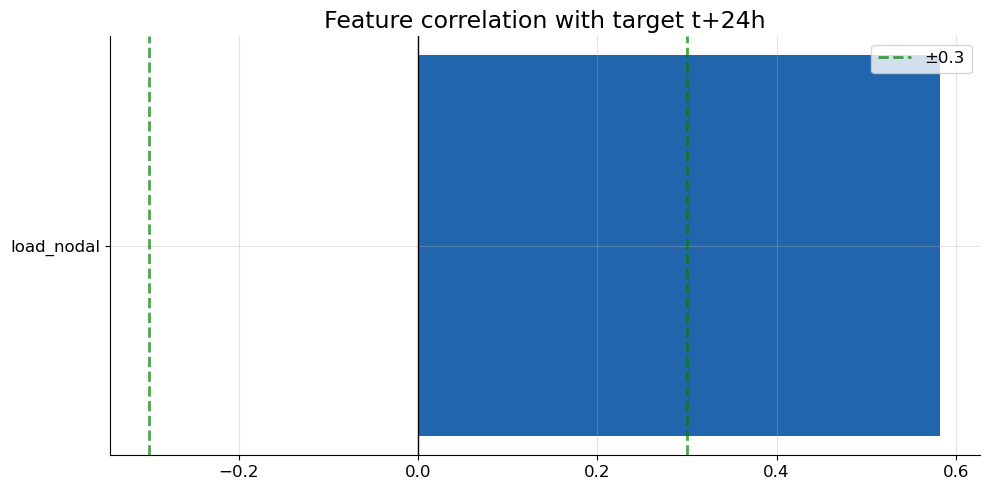

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.rcParams.update({
    "figure.figsize": (14, 5), "axes.titlesize": 17, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 19, "lines.linewidth": 2.0, "axes.grid": True,
    "grid.alpha": 0.35, "axes.spines.top": False, "axes.spines.right": False,
})

def _get(*names, default=None):
    for n in names:
        if n in globals(): return globals()[n]
    return default

def _to3d(arr, n_gen, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3: return arr
    if arr.ndim == 2: return arr.reshape(arr.shape[0] // n_gen, n_gen, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

def _mae(a, b):
    return float(np.mean(np.abs(np.asarray(a).ravel() - np.asarray(b).ravel())))

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a).ravel() - np.asarray(b).ravel())**2)))

N_GEN_  = _get("N_GEN",  default=15)
HOR_    = _get("HOR", "HORIZON_HOURS", default=24)
CONFIG_ = _get("CONFIG", default={})
ts_     = np.asarray(_get("ts_p", "ts", default=np.arange(8784)))

train_out_ = _get("train_out")
val_out_   = _get("val_out")
test_out_  = _get("test_out")

p_target_          = _get("p_bus_generator")
dyn_tensor_        = _get("dyn_tensor")
dyn_feature_names_ = _get("dyn_feature_names")
history_           = _get("history")
GEN_IDX_           = _get("GENERATOR_BUS_IDX", default=list(range(N_GEN_)))
buses_df_          = _get("buses_df")

def bus_name(global_idx):
    if buses_df_ is not None:
        try: return str(buses_df_.iloc[global_idx]["Name"])
        except Exception: pass
    return f"Bus{global_idx+1}"

def autocorr_1d(y, lag=1):
    y = np.asarray(y, dtype=float)
    valid = y[~np.isnan(y)]
    if len(valid) <= lag: return np.nan
    return float(np.corrcoef(valid[:-lag], valid[lag:])[0, 1])

print("=" * 70)
print("GIANT DIAGNOSTIC CELL — GNN Spatial Elec")
print("=" * 70)


print("\n--- SECTION : Error per prediction horizon (test set) ---")
if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)
    horizon_rows = [{"h": h+1, "model_MAE": _mae(y_true3[:,:,h], y_pred3[:,:,h]),
                     "model_RMSE": _rmse(y_true3[:,:,h], y_pred3[:,:,h])}
                    for h in range(HOR_)]
    hor_df = pd.DataFrame(horizon_rows)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(hor_df["h"], hor_df["model_MAE"],  color="#2166ac", lw=2.5, marker="o", ms=4)
    axes[0].set_title("MAE per Horizon (Test set)"); axes[0].set_xlabel("Prediction horizon (h)"); axes[0].set_ylabel("MAE")
    axes[1].plot(hor_df["h"], hor_df["model_RMSE"], color="#d73027", lw=2.5, marker="s", ms=4)
    axes[1].set_title("RMSE per Horizon (Test set)"); axes[1].set_xlabel("Prediction horizon (h)"); axes[1].set_ylabel("RMSE")
    plt.suptitle("Section 3 — Horizon-Wise Error (Test Set)", fontweight="bold")
    plt.tight_layout(); plt.show()
    print(f"  RMSE h=1: {hor_df.iloc[0]['model_RMSE']:.4f}  |  RMSE h=24: {hor_df.iloc[-1]['model_RMSE']:.4f}")

# ── Section : STD ratio per node ────────────────────────────────────────────
print("\n--- SECTION : Smoothing analysis ---")
if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)
    node_std_rows = []
    for j in range(N_GEN_):
        std_t  = float(np.std(y_true3[:, j, :]))
        std_p  = float(np.std(y_pred3[:, j, :]))
        gen_idx = GEN_IDX_[j] if j < len(GEN_IDX_) else j
        node_std_rows.append({"bus_j": j, "global_bus_idx": gen_idx,
                               "bus_name": bus_name(gen_idx),
                               "std_true": std_t, "std_pred": std_p,
                               "ratio": std_p / (std_t + 1e-9)})
    node_std_df = pd.DataFrame(node_std_rows).sort_values("ratio")
    pct_under   = float((node_std_df["ratio"] < 0.8).mean()) * 100
    agg_true    = y_true3.sum(axis=1)
    agg_pred    = y_pred3.sum(axis=1)
    agg_std_ratio = float(np.std(agg_pred)) / (float(np.std(agg_true)) + 1e-9)
    print(f"  Mean per-node STD ratio : {node_std_df['ratio'].mean():.3f}")
    print(f"  Aggregated STD ratio    : {agg_std_ratio:.3f}")
    print(f"  % buses with ratio < 0.8: {pct_under:.1f}%")

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    colors_bar = ["#d73027" if r < 0.8 else "#4d9221" for r in node_std_df["ratio"]]
    axes[0].barh(range(len(node_std_df)), node_std_df["ratio"], color=colors_bar)
    axes[0].axvline(1.0, color="black", ls="-", lw=1.5, label="Ideal = 1")
    axes[0].axvline(0.8, color="orange", ls="--", lw=1.5, label="Under-var 0.8")
    axes[0].set_yticks(range(len(node_std_df)))
    axes[0].set_yticklabels(node_std_df["bus_name"].values, fontsize=10)
    axes[0].set_title(f"std(pred)/std(true) per Bus (Test) — {pct_under:.0f}% under-varied")
    axes[0].set_xlabel("STD ratio"); axes[0].legend()
    n_samp = min(3000, len(agg_true.ravel()))
    idx_s  = np.random.choice(len(agg_true.ravel()), n_samp, replace=False)
    lim    = max(np.abs(agg_true.ravel()).max(), np.abs(agg_pred.ravel()).max())
    axes[1].scatter(agg_true.ravel()[idx_s], agg_pred.ravel()[idx_s], alpha=0.25, s=8, color="#4575b4")
    axes[1].plot([0, lim], [0, lim], "k--", lw=1.5, label="Perfect")
    axes[1].set_title(f"Aggregated Total — STD ratio = {agg_std_ratio:.3f}")
    axes[1].set_xlabel("True total"); axes[1].set_ylabel("Predicted total"); axes[1].legend()
    plt.suptitle("Section 4 — Variability Smoothing", fontweight="bold")
    plt.tight_layout(); plt.show()

# ── Section : Feature-target correlation ────────────────────────────────────
print("\n--- SECTION : Dynamic feature – target correlation (lag = horizon) ---")
if dyn_tensor_ is not None and p_target_ is not None:
    T_data     = min(dyn_tensor_.shape[0], p_target_.shape[0])
    F_dyn      = dyn_tensor_.shape[-1]
    feat_names = dyn_feature_names_ if dyn_feature_names_ is not None else [f"dyn_{i}" for i in range(F_dyn)]
    target_total = np.nansum(p_target_[:T_data], axis=1)
    lag = HOR_
    corr_rows = []
    for k in range(F_dyn):
        feat_mean = np.nanmean(dyn_tensor_[:T_data, :, k], axis=1)
        valid = ~(np.isnan(feat_mean) | np.isnan(target_total))
        x, y  = feat_mean[valid], target_total[valid]
        corr_val = float(np.corrcoef(x[:-lag], y[lag:])[0, 1]) if len(x) > lag + 10 else np.nan
        corr_rows.append({"feature": feat_names[k], f"corr_t+{lag}h": corr_val})
    corr_df  = pd.DataFrame(corr_rows).sort_values(f"corr_t+{lag}h", key=abs, ascending=False)
    col_key  = f"corr_t+{lag}h"
    print(corr_df.to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_c = ["#2166ac" if abs(v) > 0.3 else "#d73027" for v in corr_df[col_key]]
    ax.barh(corr_df["feature"], corr_df[col_key], color=colors_c)
    ax.axvline(0.0, color="black", lw=1)
    ax.axvline(0.3, color="green", ls="--", alpha=0.7, label="±0.3")
    ax.axvline(-0.3, color="green", ls="--", alpha=0.7)
    ax.set_title(f"Feature correlation with target t+{lag}h"); ax.legend()
    plt.tight_layout(); plt.show()


In [323]:

class NoMessagePassingElec(nn.Module):
    def __init__(self, in_dim, hidden_dim, horizon,
                 encoder_hidden_dims=(256, 128), decoder_hidden_dims=(128, 64),
                 dropout=0.0, use_batchnorm=True,
                 use_day_embedding=False, day_emb_dim=3):
        super().__init__()

        self.use_day_embedding = use_day_embedding

        if use_day_embedding:
            self.day_embedding = nn.Embedding(7, day_emb_dim)
            enc_in_dim = in_dim + day_emb_dim
        else:
            enc_in_dim = in_dim

        enc_dims = [enc_in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(
            enc_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False
        )

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(
            dec_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False
        )

    def forward(self, x, edge_index, edge_attr, generator_mask, dow=None, batch_idx=None):
        if self.use_day_embedding and dow is not None and batch_idx is not None:
            dow_emb = self.day_embedding(dow)
            x = torch.cat([x, dow_emb[batch_idx]], dim=1)

        h = self.encoder(x)
        h_gen = h[generator_mask]

        return self.decoder(h_gen)


ablation_model = NoMessagePassingElec(
    in_dim              = expected_x_dim,
    hidden_dim          = CONFIG["HIDDEN_DIM"],
    horizon             = HOR,
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    dropout             = CONFIG["DROPOUT"],
    use_batchnorm       = CONFIG["USE_BATCHNORM"],
    use_day_embedding   = use_day_embedding,
    day_emb_dim         = day_emb_dim,
).to(DEVICE)

ablation_optimizer = torch.optim.Adam(
    ablation_model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"]
)

ablation_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ablation_optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"]
)

ablation_early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG["EARLY_STOPPING_MIN_DELTA"]
)

ablation_history = {
    "train_loss": [],
    "val_loss": [],
    "lr": []
}

print("=== Model without message passing ===")
print(ablation_model)

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(
        ablation_model,
        train_loader,
        optimizer=ablation_optimizer
    )

    val_loss = run_one_epoch(
        ablation_model,
        val_loader,
        optimizer=None
    )

    ablation_scheduler.step(val_loss)
    current_lr = ablation_optimizer.param_groups[0]["lr"]

    ablation_history["train_loss"].append(train_loss)
    ablation_history["val_loss"].append(val_loss)
    ablation_history["lr"].append(current_lr)

    print(
        f"[NoMP] Epoch {epoch:03d} | "
        f"train={train_loss:.6f} | "
        f"val={val_loss:.6f} | "
        f"lr={current_lr:.2e}"
    )

    if ablation_early_stopper.step(val_loss, ablation_model):
        print(f"[NoMP] Early stopping triggered at epoch {epoch}.")
        break

assert ablation_early_stopper.best_state is not None

ablation_model.load_state_dict(ablation_early_stopper.best_state)

print("\n[NoMP] Best val_loss:", ablation_early_stopper.best_loss)


ablation_train_out = collect_predictions(ablation_model, train_loader)
ablation_val_out   = collect_predictions(ablation_model, val_loader)
ablation_test_out  = collect_predictions(ablation_model, test_loader)


def evaluate_output_dict_elec(out, split_name, model_prefix):
    preds_3d = ensure_3d_output(out["preds_real"], N_GEN, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_GEN, HOR)

    rows = []

    # Global metrics over all generators and horizons
    m = mae_rmse_nmae(trues_3d, preds_3d)
    m.update({
        "split": split_name,
        "model": f"{model_prefix}_global"
    })
    rows.append(m)

    # Per-generator metrics
    for j, bus_idx in enumerate(CONFIG["GENERATOR_BUS_IDX"]):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])

        if "buses_df" in globals() and bus_idx in buses_df.index:
            bus_name = buses_df.iloc[bus_idx]["Name"]
        else:
            bus_name = f"bus_{bus_idx}"

        m.update({
            "split": split_name,
            "model": f"{model_prefix}_bus_{bus_idx}",
            "bus_global_idx": bus_idx,
            "bus_name": bus_name
        })
        rows.append(m)

    return pd.DataFrame(rows)


ablation_metrics_df = pd.concat([
    evaluate_output_dict_elec(ablation_train_out, "train", "NoMP"),
    evaluate_output_dict_elec(ablation_val_out,   "val",   "NoMP"),
    evaluate_output_dict_elec(ablation_test_out,  "test",  "NoMP"),
], ignore_index=True)



=== Model without message passing ===
NoMessagePassingElec(
  (day_embedding): Embedding(7, 3)
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=76, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=64, out_features=32, bias=True)
      (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=32, out_features=1024, bias=True)
    )
  )
  (decoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=1024, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=32, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.

In [324]:
def aggregate_totals_per_hour(arr, n_gen, horizon):
    return ensure_3d_output(arr, n_gen, horizon).sum(axis=1)

gnn_test_pred_tot  = aggregate_totals_per_hour(test_out["preds_real"], N_GEN, HOR)
gnn_test_true_tot  = aggregate_totals_per_hour(test_out["trues_real"], N_GEN, HOR)
nomp_test_pred_tot = aggregate_totals_per_hour(ablation_test_out["preds_real"], N_GEN, HOR)
nomp_test_true_tot = aggregate_totals_per_hour(ablation_test_out["trues_real"], N_GEN, HOR)

rows = []
for label, true_tot, pred_tot in [
    ("SpatialElecGNN_aggregated_total", gnn_test_true_tot, gnn_test_pred_tot),
    ("NoMessagePassing_aggregated_total", nomp_test_true_tot, nomp_test_pred_tot),
]:
    m = mae_rmse_nmae(true_tot, pred_tot)
    m["model"] = label
    rows.append(m)

agg_total_df = pd.DataFrame(rows)[["model", "MAE", "RMSE", "NMAE"]].sort_values("RMSE").reset_index(drop=True)
print("=== TEST comparison on AGGREGATED TOTALS ===")
display(agg_total_df)

gnn_rmse  = agg_total_df.loc[agg_total_df["model"] == "SpatialElecGNN_aggregated_total", "RMSE"]
nomp_rmse = agg_total_df.loc[agg_total_df["model"] == "NoMessagePassing_aggregated_total", "RMSE"]

if len(gnn_rmse) and len(nomp_rmse):
    rel_gap = 100 * (nomp_rmse.iloc[0] - gnn_rmse.iloc[0]) / max(abs(gnn_rmse.iloc[0]), 1e-12)
    print(f"Relative RMSE gap between NoMP and GNN on aggregated totals = {rel_gap:.2f}%")


=== TEST comparison on AGGREGATED TOTALS ===


,model,MAE,RMSE,NMAE
0,SpatialElecGNN_aggregated_total,11.108513,13.606019,0.170773
1,NoMessagePassing_aggregated_total,11.394350,13.752886,0.175167


Relative RMSE gap between NoMP and GNN on aggregated totals = 1.08%


In [325]:
def roughness(x):
    x = np.asarray(x).reshape(-1)
    return float(np.mean(np.abs(np.diff(x)))) if len(x) >= 2 else 0.0

rows = []
for label, true_tot, pred_tot in [
    ("SpatialElecGNN", gnn_test_true_tot, gnn_test_pred_tot),
    ("NoMessagePassing", nomp_test_true_tot, nomp_test_pred_tot),
]:
    rows.append({
        "model": label,
        "rough_true": roughness(true_tot),
        "rough_pred": roughness(pred_tot),
        "rough_error": roughness(pred_tot - true_tot),
    })

roughness_df = pd.DataFrame(rows)
roughness_df["pred_minus_true"] = roughness_df["rough_pred"] - roughness_df["rough_true"]
roughness_df["pred_over_true"] = roughness_df["rough_pred"] / np.maximum(roughness_df["rough_true"], 1e-12)

print("=== Roughness on AGGREGATED TOTALS (TEST) ===")
display(roughness_df)

print("\n=== Quick reading ===")
for _, r in roughness_df.iterrows():
    print(f"{r['model']}:")
    print(f"  rough_true={r['rough_true']:.4f}  rough_pred={r['rough_pred']:.4f}  pred/true={r['pred_over_true']:.3f}")

=== Roughness on AGGREGATED TOTALS (TEST) ===


,model,rough_true,rough_pred,rough_error,pred_minus_true,pred_over_true
0,SpatialElecGNN,2.69092,3.357507,3.210662,0.666587,1.247717
1,NoMessagePassing,2.69092,2.664559,2.703701,-0.026361,0.990204



=== Quick reading ===
SpatialElecGNN:
  rough_true=2.6909  rough_pred=3.3575  pred/true=1.248
NoMessagePassing:
  rough_true=2.6909  rough_pred=2.6646  pred/true=0.990


,feature,corr
0,load_nodal,0.582999


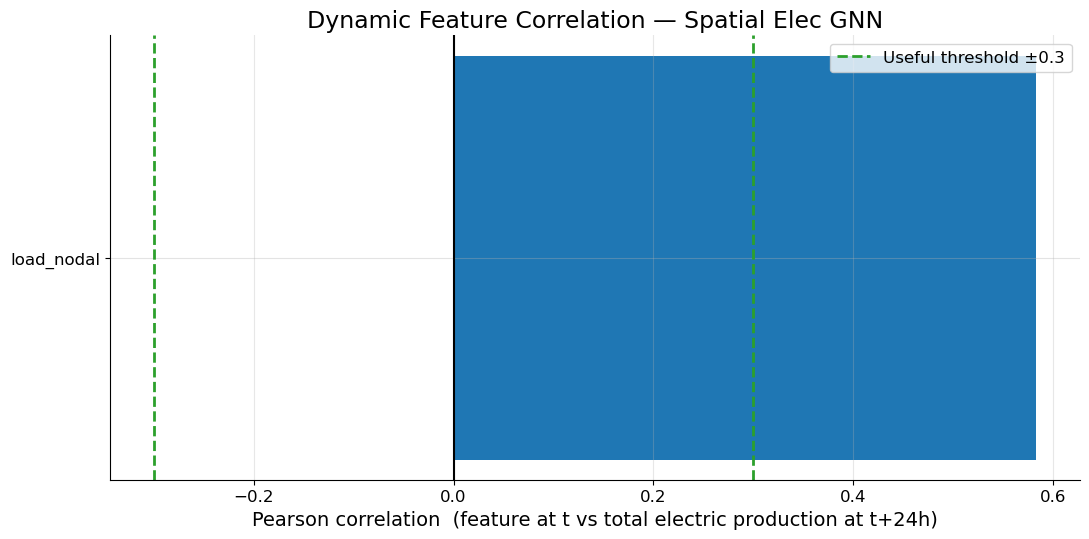

In [326]:
H = 24                  
USE_ABS = False          
THRESH = 0.30            
# p_bus_generator : [T, N_GEN]
target_total = np.asarray(p_bus_generator).sum(axis=1)   # shape [T]

feature_corrs = []

for f_idx, feat_name in enumerate(dyn_feature_names):
    feat_arr = np.asarray(dyn_tensor[:, :, f_idx])   # [T, N_nodes]


    feat_series = feat_arr.mean(axis=1)              # [T]

    x = feat_series[:-H]
    y = target_total[H:]

    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 3:
        corr = np.corrcoef(x[mask], y[mask])[0, 1]
    else:
        corr = np.nan

    feature_corrs.append({
        "feature": feat_name,
        "corr": corr,
    })

corr_df = pd.DataFrame(feature_corrs)

if USE_ABS:
    corr_df["abs_corr"] = corr_df["corr"].abs()
    corr_df = corr_df.sort_values("abs_corr", ascending=True).reset_index(drop=True)
else:
    corr_df = corr_df.sort_values("corr", ascending=True).reset_index(drop=True)

display(corr_df)


colors = ["tab:blue" if c >= 0 else "tab:red" for c in corr_df["corr"]]

plt.figure(figsize=(11, 5.5))
plt.barh(corr_df["feature"], corr_df["corr"], color=colors)
plt.axvline(0.0, color="black", linewidth=1.5)
plt.axvline(+THRESH, color="tab:green", linestyle="--", linewidth=2, label=f"Useful threshold ±{THRESH}")
plt.axvline(-THRESH, color="tab:green", linestyle="--", linewidth=2)

plt.xlabel(f"Pearson correlation  (feature at t vs total electric production at t+{H}h)")
plt.title("Dynamic Feature Correlation — Spatial Elec GNN")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [327]:
OFF_RATIO = 0.02   
ON_RATIO  = 0.10   
SCALE_MODE = "q95" 
EPS = 1e-12


pred_3d = ensure_3d_output(test_out["preds_real"], N_GEN, HOR)
true_3d = ensure_3d_output(test_out["trues_real"], N_GEN, HOR)

true_flat = true_3d.reshape(-1, N_GEN)  # [n_windows*HOR, n_gen]
scales = np.zeros(N_GEN)

for g in range(N_GEN):
    vals = true_flat[:, g]
    vals = vals[np.isfinite(vals)]

    vals_pos = vals[vals > 0]

    if len(vals_pos) == 0:
        scales[g] = 1.0
    else:
        if SCALE_MODE == "q95":
            scales[g] = np.percentile(vals_pos, 95)
        elif SCALE_MODE == "max":
            scales[g] = np.max(vals_pos)
        elif SCALE_MODE == "mean_pos":
            scales[g] = np.mean(vals_pos)
        else:
            raise ValueError("SCALE_MODE must be 'q95', 'max', or 'mean_pos'.")

    if not np.isfinite(scales[g]) or scales[g] < EPS:
        scales[g] = 1.0

rows = []

for g in range(N_GEN):
    scale_g = scales[g]
    off_thr = OFF_RATIO * scale_g
    on_thr  = ON_RATIO  * scale_g

    true_g = true_3d[:, :, g]
    pred_g = pred_3d[:, :, g]

    off_mask  = (true_g < off_thr)
    fail_mask = off_mask & (pred_g > on_thr)

    n_off  = int(off_mask.sum())
    n_fail = int(fail_mask.sum())

    rows.append({
        "generator": generator_names[g] if "generator_names" in globals() else f"G{g}",
        "scale_gen": scale_g,
        "off_threshold": off_thr,
        "on_threshold": on_thr,
        "n_true_off": n_off,
        "failures": n_fail,
        "failure_rate_percent": 100.0 * n_fail / max(n_off, 1)
    })

fail_df = pd.DataFrame(rows).sort_values("failures", ascending=True).reset_index(drop=True)

print("=== ON/OFF failures with relative thresholds ===")
display(fail_df)

=== ON/OFF failures with relative thresholds ===


,generator,scale_gen,off_threshold,on_threshold,n_true_off,failures,failure_rate_percent
0,G10,19.290001,0.3858,1.929,269,58,21.561338
1,G13,19.290001,0.3858,1.929,308,65,21.103896
2,G12,19.290001,0.3858,1.929,315,68,21.587302
3,G9,19.290001,0.3858,1.929,268,70,26.119403
4,G14,19.290001,0.3858,1.929,302,70,23.178808
5,G11,19.290001,0.3858,1.929,297,79,26.599327
6,G0,19.290001,0.3858,1.929,372,82,22.043011
7,G8,12.420000,0.2484,1.242,279,92,32.974910
8,G1,19.290001,0.3858,1.929,414,93,22.463768
9,G2,19.290001,0.3858,1.929,449,93,20.712695


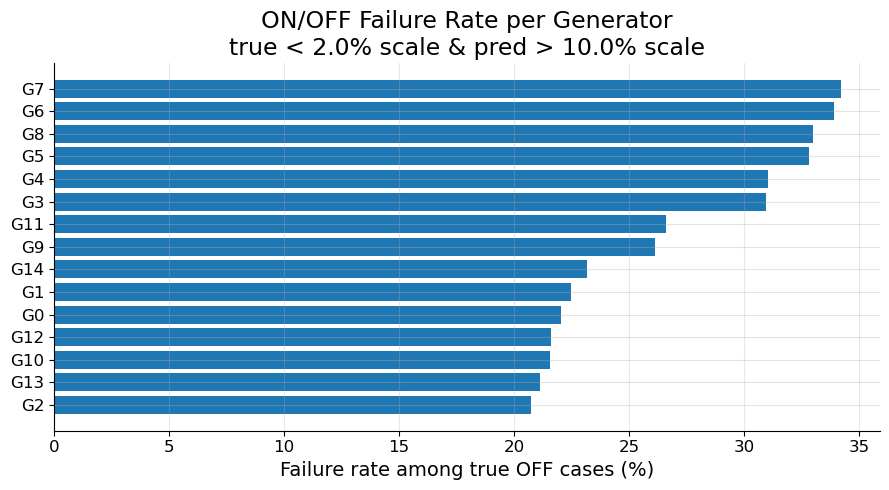

In [328]:
fail_rate_df = fail_df.sort_values("failure_rate_percent", ascending=True).reset_index(drop=True)

plt.figure(figsize=(9, 5))
plt.barh(fail_rate_df["generator"], fail_rate_df["failure_rate_percent"])
plt.xlabel("Failure rate among true OFF cases (%)")
plt.title(
    f"ON/OFF Failure Rate per Generator\n"
    f"true < {100*OFF_RATIO:.1f}% scale & pred > {100*ON_RATIO:.1f}% scale"
)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()